In [1]:
import keras
print("Keras version:", keras.__version__)
keras.config.set_dtype_policy("float32")  # Prevent dtype warnings

Keras version: 3.9.0


In [2]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [3]:
# EDA

In [4]:
import yfinance as yf

In [5]:
from datetime import datetime
end = datetime.now()
start = datetime(end.year-20, end.month, end.day)

In [6]:
stock = "GOOG"
google_data = yf.download(stock, start, end, auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


In [7]:
google_data.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,,
2005-06-09,7.097404,7.131021,7.185567,6.987808,7.091420,660109011
2005-06-10,7.002958,7.036127,7.155181,6.974358,7.147958,509767599
2005-06-13,7.009156,7.042354,7.078219,6.887185,6.969377,514047581
2005-06-14,6.900082,6.932764,7.004744,6.917820,6.938742,405189077
2005-06-15,6.812081,6.844346,6.906612,6.660784,6.849327,838454999


In [8]:
google_data.shape

(5031, 6)

In [9]:
google_data.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG
count,5031.000000,5031.000000,5031.000000,5031.000000,5031.000000,5.031000e+03
mean,52.107715,52.328992,52.870314,51.775369,52.308450,9.898387e+07
std,49.392998,49.563998,50.106841,49.024816,49.537525,1.245565e+08
min,6.381739,6.411966,6.709103,6.159413,6.538243,1.584340e+05
25%,13.796199,13.861544,14.055317,13.677608,13.873250,2.589600e+07
50%,29.446798,29.586271,29.814997,29.342766,29.568819,4.629800e+07
75%,72.268208,72.610500,73.335751,71.674999,72.510502,1.222164e+08
max,207.473633,207.710007,208.699997,204.259995,204.500000,1.650833e+09


In [10]:
google_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5031 entries, 2005-06-09 to 2025-06-06
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, GOOG)  5031 non-null   float64
 1   (Close, GOOG)      5031 non-null   float64
 2   (High, GOOG)       5031 non-null   float64
 3   (Low, GOOG)        5031 non-null   float64
 4   (Open, GOOG)       5031 non-null   float64
 5   (Volume, GOOG)     5031 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 275.1 KB


In [11]:
google_data.isna().sum()

Price      Ticker
Adj Close  GOOG      0
Close      GOOG      0
High       GOOG      0
Low        GOOG      0
Open       GOOG      0
Volume     GOOG      0
dtype: int64

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

Text(0.5, 1.0, 'Closing price of Google data')

<Figure size 1500x500 with 0 Axes>

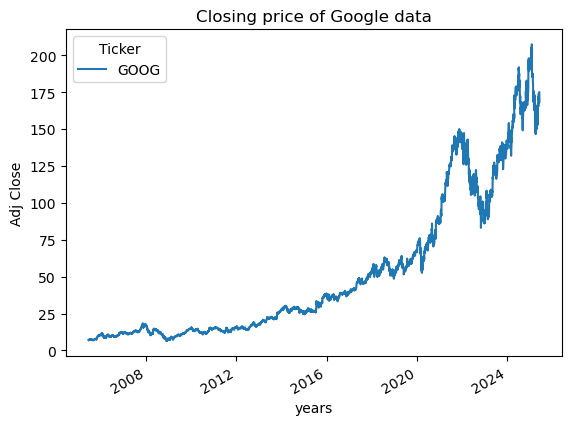

In [13]:
plt.figure(figsize = (15,5))
google_data['Adj Close'].plot()
plt.xlabel("years")
plt.ylabel("Adj Close")
plt.title("Closing price of Google data")

In [14]:
def plot_graph(figsize, values, column_name):
    plt.figure()
    values.plot(figsize = figsize)
    plt.xlabel("years")
    plt.ylabel(column_name)
    plt.title(f"{column_name} of Google data")

In [15]:
google_data.columns


MultiIndex([('Adj Close', 'GOOG'),
            (    'Close', 'GOOG'),
            (     'High', 'GOOG'),
            (      'Low', 'GOOG'),
            (     'Open', 'GOOG'),
            (   'Volume', 'GOOG')],
           names=['Price', 'Ticker'])

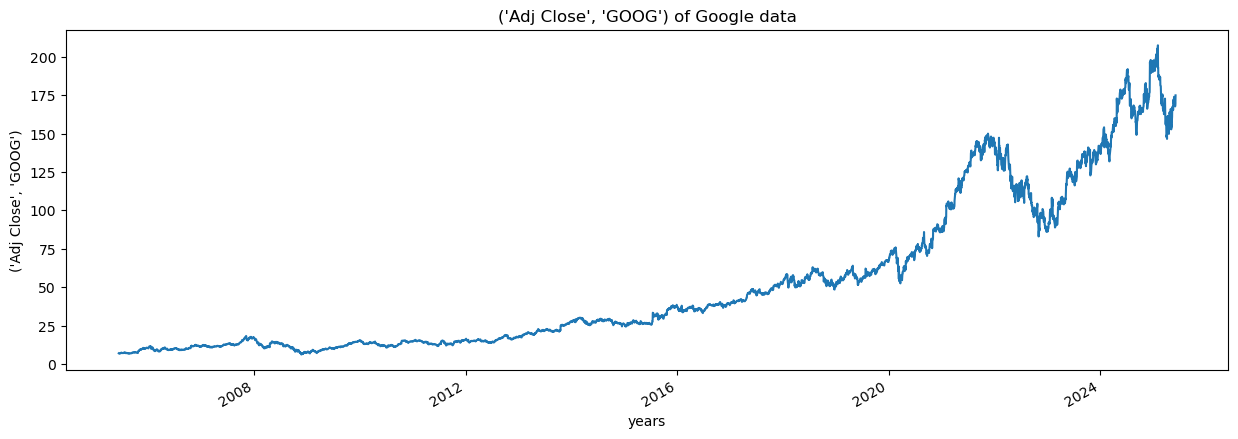

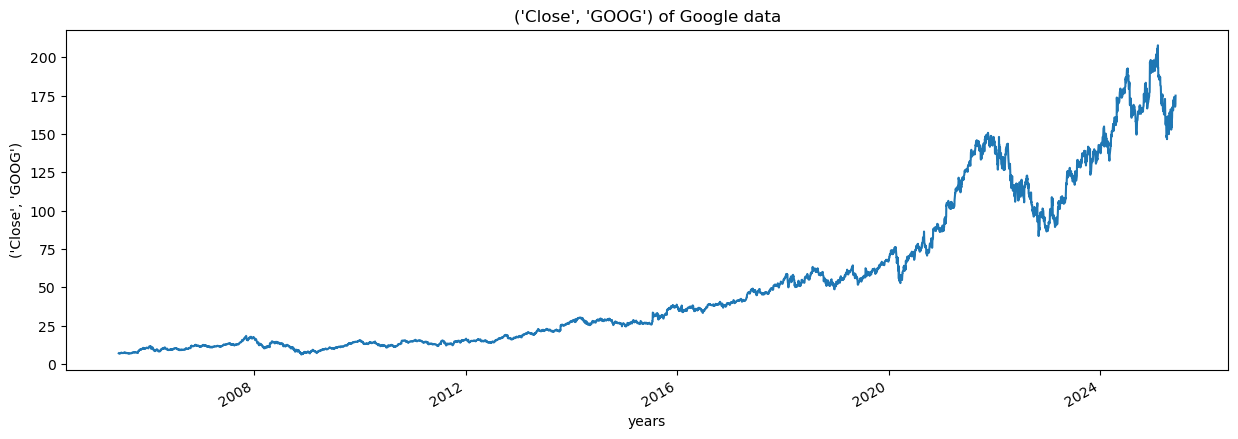

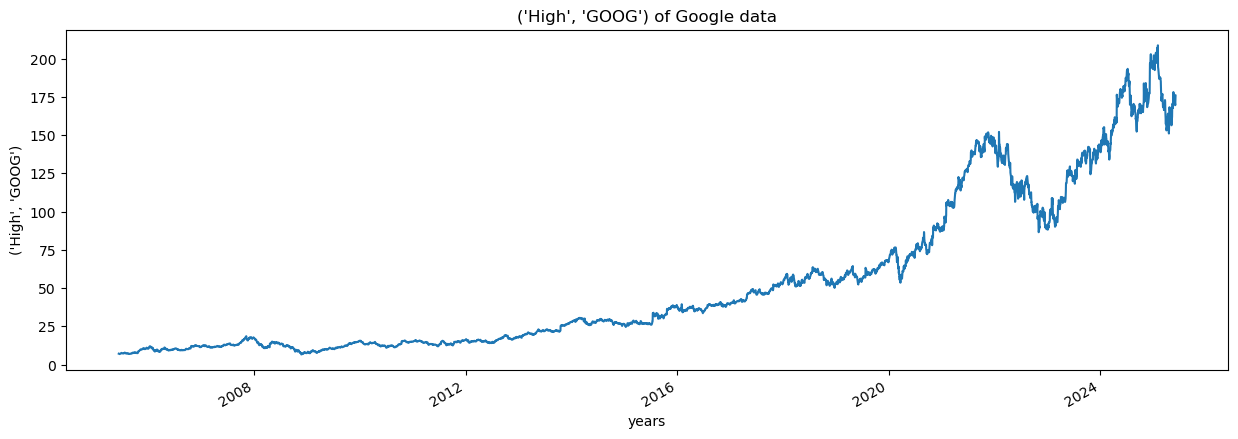

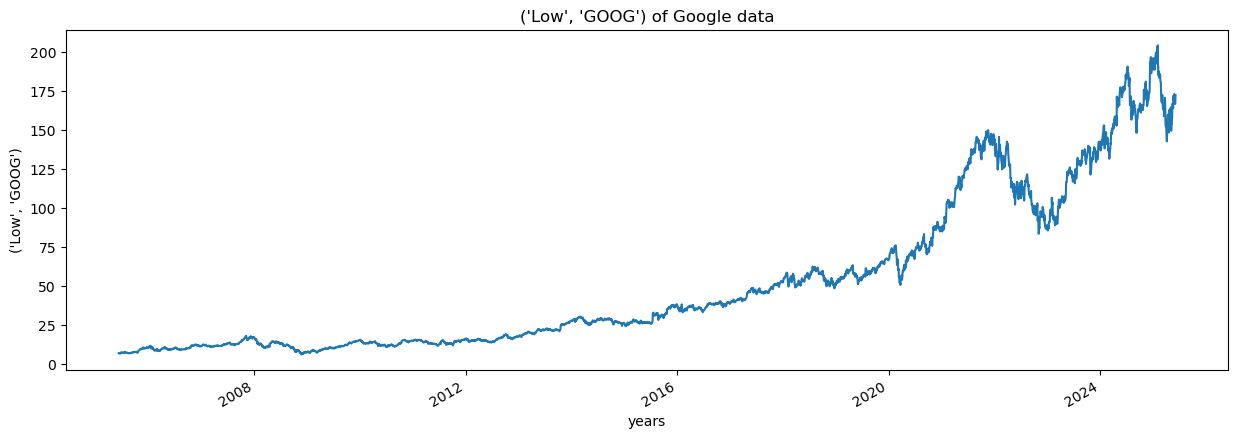

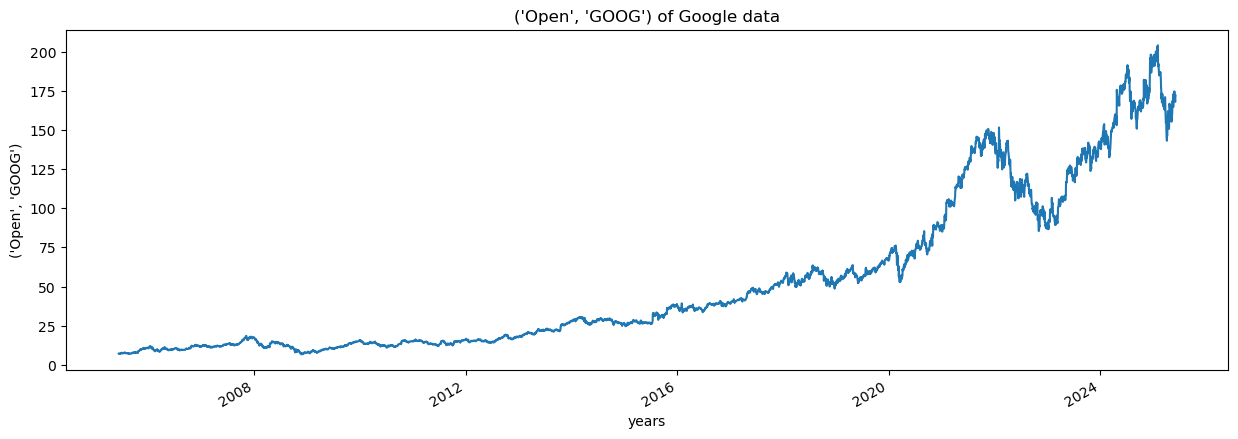

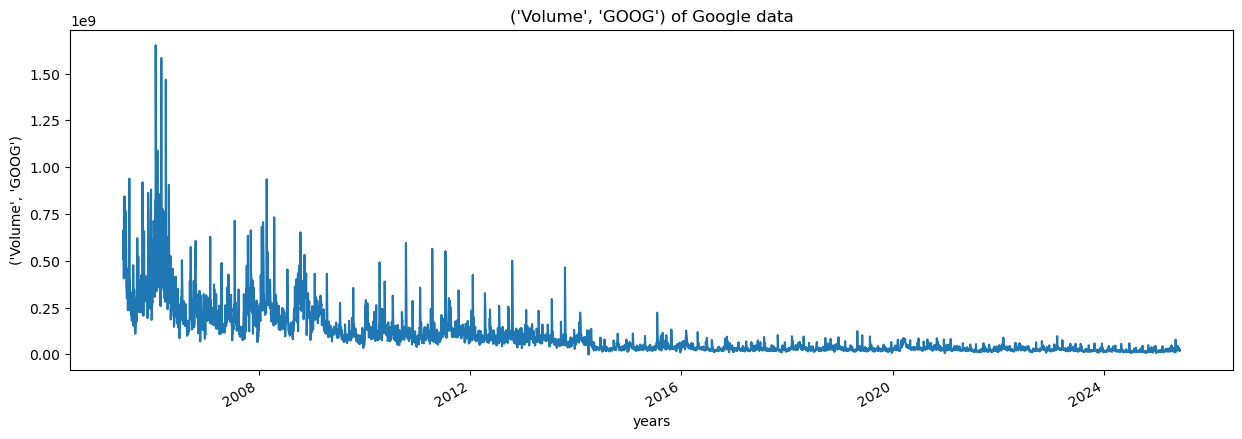

In [16]:
for column in google_data.columns:
    plot_graph((15,5),google_data[column], column)

In [17]:
# 10, 20, 30, 40, 50, 60, 70, 80, 90, 100

# MA for 5 days ==> null null null null 30 40 50 60 70 80

In [18]:
temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(sum(temp_data[:5])/5)

30.0


In [19]:
# now Calculate MA for first 6 days:
temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(sum(temp_data[1:6])/5)

40.0


In [20]:
import pandas as pd
data = pd.DataFrame([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
data.head()

,0
0,10
1,20
2,30
3,40
4,50


In [21]:
data['MA'] = data.rolling(5).mean()
data

,0,MA
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


In [22]:
for i in range(2005,2026):
    print(i,list(google_data.index.year).count(i))

2005 143
2006 251
2007 251
2008 253
2009 252
2010 252
2011 252
2012 250
2013 252
2014 252
2015 252
2016 252
2017 251
2018 251
2019 252
2020 253
2021 252
2022 251
2023 250
2024 252
2025 107


In [23]:
google_data['MA_for_250_days'] = google_data['Adj Close'].rolling(250).mean()


In [24]:
google_data['MA_for_250_days']


Date
2005-06-09           NaN
2005-06-10           NaN
2005-06-13           NaN
2005-06-14           NaN
2005-06-15           NaN
                 ...    
2025-06-02    173.532894
2025-06-03    173.509343
2025-06-04    173.489686
2025-06-05    173.463984
2025-06-06    173.453628
Name: MA_for_250_days, Length: 5031, dtype: float64

In [25]:
google_data['MA_for_250_days'][0:250].tail()


Date
2006-05-31         NaN
2006-06-01         NaN
2006-06-02         NaN
2006-06-05         NaN
2006-06-06    8.878552
Name: MA_for_250_days, dtype: float64

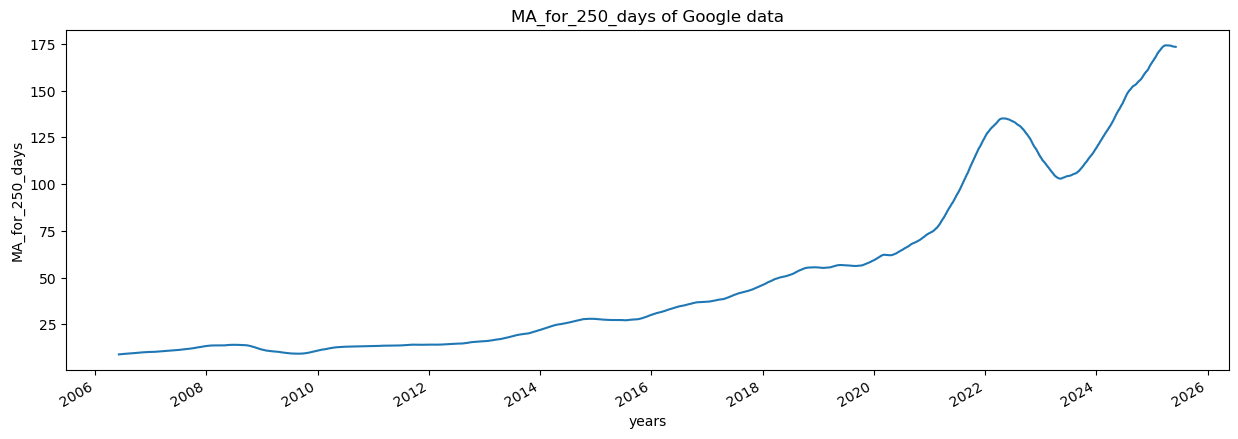

In [26]:
plot_graph((15,5), google_data['MA_for_250_days'], 'MA_for_250_days')


<Figure size 640x480 with 0 Axes>

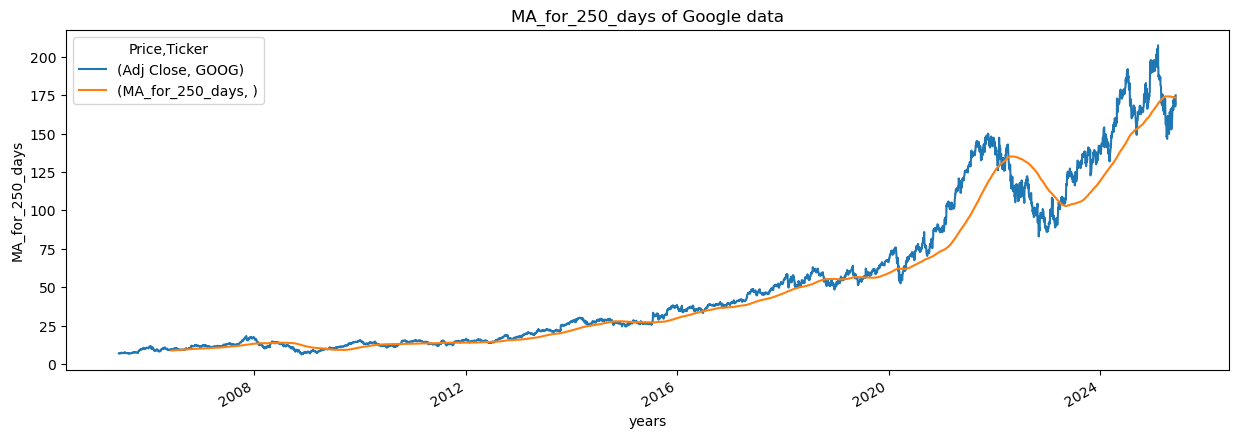

In [27]:
plot_graph((15,5), google_data[['Adj Close','MA_for_250_days']], 'MA_for_250_days')


<Figure size 640x480 with 0 Axes>

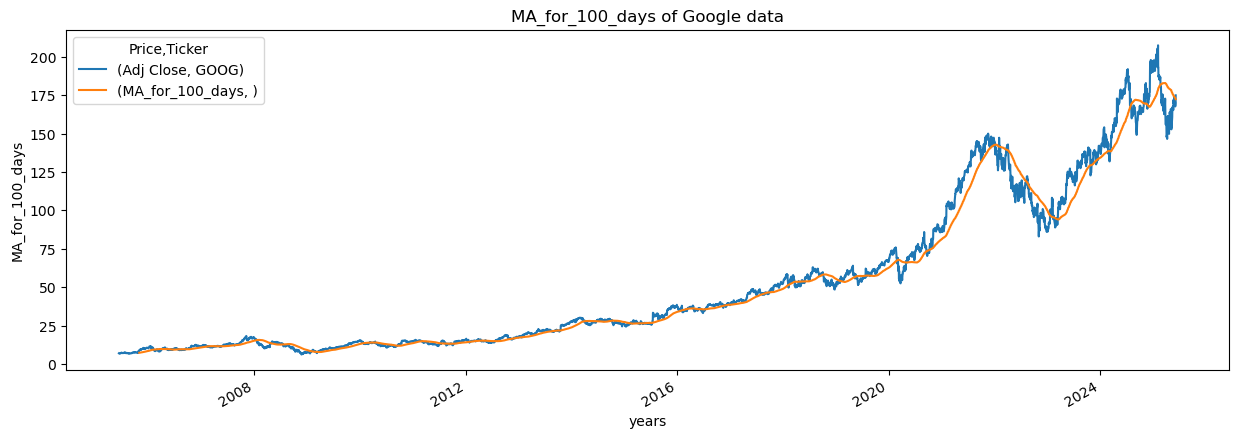

In [28]:
google_data['MA_for_100_days'] = google_data['Adj Close'].rolling(100).mean()
plot_graph((15,5), google_data[['Adj Close','MA_for_100_days']], 'MA_for_100_days')

<Figure size 640x480 with 0 Axes>

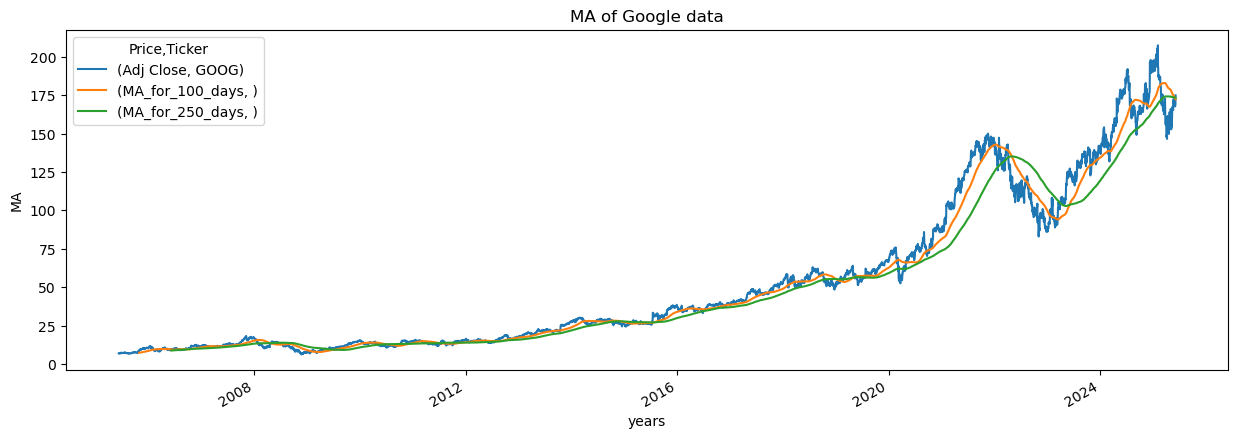

In [29]:
plot_graph((15,5), google_data[['Adj Close','MA_for_100_days', 'MA_for_250_days']], 'MA')


In [30]:
google_data['percentage_change_cp'] = google_data['Adj Close'].pct_change()
google_data[['Adj Close','percentage_change_cp']].head()

Price,Adj Close,percentage_change_cp
Ticker,GOOG,
Date,,
2005-06-09,7.097404,NaN
2005-06-10,7.002958,-0.013307
2005-06-13,7.009156,0.000885
2005-06-14,6.900082,-0.015562
2005-06-15,6.812081,-0.012754


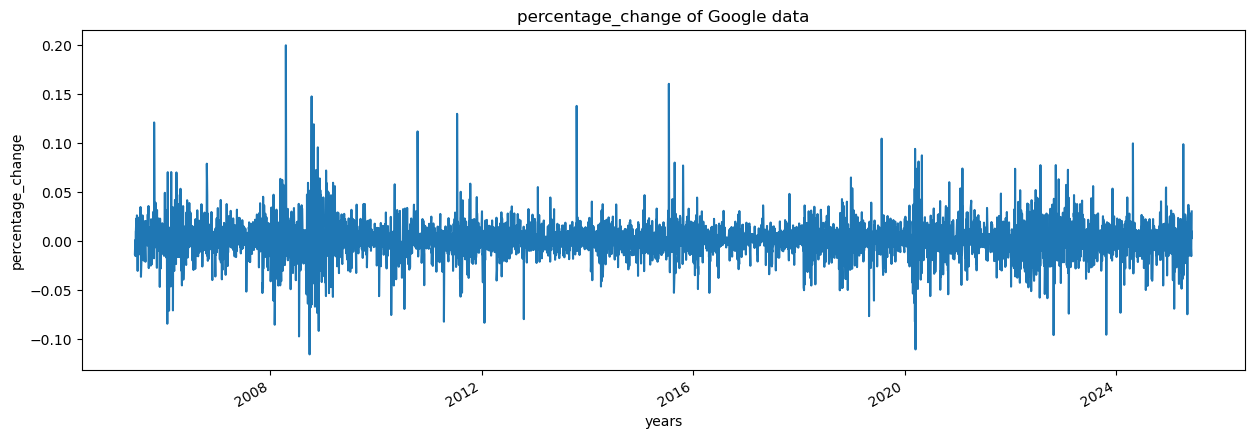

In [31]:
plot_graph((15,5), google_data['percentage_change_cp'], 'percentage_change')


In [32]:
# Preprocessing 

In [33]:
Adj_close_price = google_data[['Adj Close']]


In [34]:
max(Adj_close_price.values),min(Adj_close_price.values) 


(array([207.47363281]), array([6.38173866]))

In [35]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(Adj_close_price)
scaled_data

array([[0.0035589 ],
       [0.00308923],
       [0.00312005],
       ...,
       [0.81061577],
       [0.81270436],
       [0.83811563]])

In [36]:
len(scaled_data)


5031

In [37]:
x_data = []
y_data = []

for i in range(100, len(scaled_data)):
    x_data.append(scaled_data[i-100:i])
    y_data.append(scaled_data[i])
    
import numpy as np
x_data, y_data = np.array(x_data), np.array(y_data)

In [38]:
x_data[0],y_data[0]


(array([[0.0035589 ],
        [0.00308923],
        [0.00312005],
        [0.00257764],
        [0.00214003],
        [0.00246547],
        [0.00281803],
        [0.00360698],
        [0.00374751],
        [0.00392748],
        [0.00397803],
        [0.00490751],
        [0.00575193],
        [0.00549305],
        [0.00434908],
        [0.00452536],
        [0.00416787],
        [0.00471767],
        [0.00420115],
        [0.00469671],
        [0.00478177],
        [0.00442674],
        [0.00423321],
        [0.00510598],
        [0.00535623],
        [0.00539321],
        [0.0051898 ],
        [0.00646691],
        [0.00672579],
        [0.00696494],
        [0.00554236],
        [0.00473493],
        [0.00476451],
        [0.00486807],
        [0.00444523],
        [0.00373765],
        [0.00421225],
        [0.00514666],
        [0.00491367],
        [0.00496668],
        [0.00430347],
        [0.00416787],
        [0.00420732],
        [0.00348124],
        [0.0032803 ],
        [0

In [39]:
int(len(x_data)*0.7)


3451

In [40]:
4908-100-int(len(x_data)*0.7)


1357

In [41]:
splitting_len = int(len(x_data)*0.7)
x_train = x_data[:splitting_len]
y_train = y_data[:splitting_len]

x_test = x_data[splitting_len:]
y_test = y_data[splitting_len:]

In [42]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(3451, 100, 1)
(3451, 1)
(1480, 100, 1)
(1480, 1)


In [43]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

model = Sequential()
model.add(Input(shape=(x_train.shape[1], 1)))  # ✅ Modern and compatible
model.add(LSTM(128, return_sequences=True))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))


In [45]:
model.compile(optimizer='adam', loss='mean_squared_error')


In [46]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [47]:
history = model.fit(
    x_train,
    y_train,
    batch_size=64,         # Faster and more stable
    epochs=20,
    validation_split=0.2,  # 20% of training data used for validation
    callbacks=[early_stop]
)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step - loss: 0.0015 - val_loss: 7.0249e-05
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 1.5999e-05 - val_loss: 6.6984e-05
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - loss: 1.2505e-05 - val_loss: 5.9378e-05
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - loss: 1.1798e-05 - val_loss: 5.9013e-05
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - loss: 1.4120e-05 - val_loss: 5.6772e-05
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - loss: 1.3354e-05 - val_loss: 6.7218e-05
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - loss: 1.1003e-05 - val_loss: 5.4149e-05
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - loss: 1.1010e-05 - val_loss: 5.4028e-05
Epoch 9/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - loss: 1.2028e-05 - val_loss: 5.2016e-05
Epoch 10/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - loss: 1.1238e-05 - val_loss: 5.3402e-05
Epoch 11/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - loss: 1

In [48]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

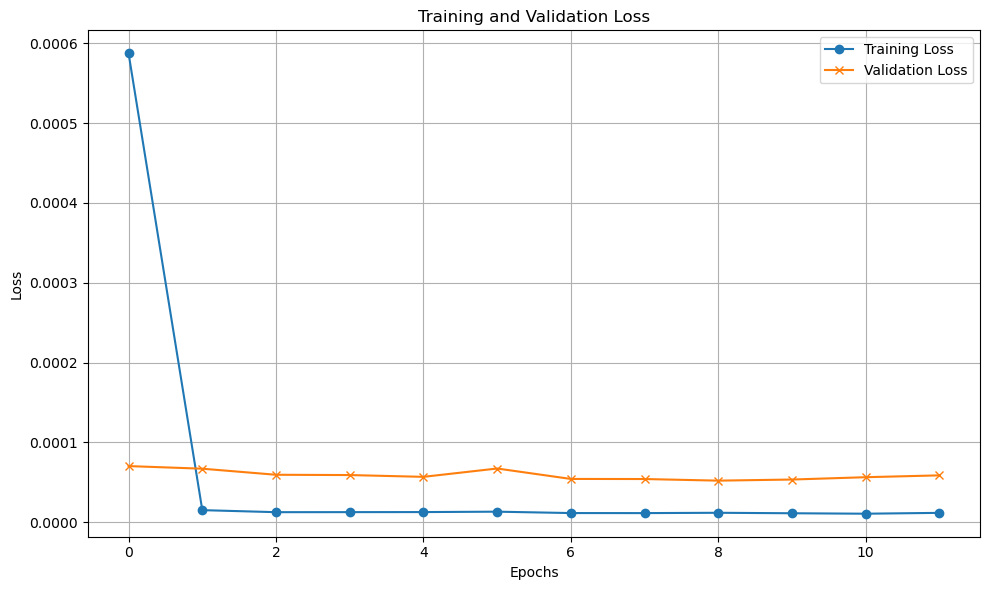

In [49]:
# Plot training & validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [50]:
predictions = model.predict(x_test)


47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step


In [51]:
predictions


array([[0.25039288],
       [0.2509069 ],
       [0.25121903],
       ...,
       [0.8066434 ],
       [0.80706745],
       [0.8069767 ]], dtype=float32)

In [52]:
inv_predictions = scaler.inverse_transform(predictions)
inv_predictions

array([[ 56.733715],
       [ 56.837082],
       [ 56.89985 ],
       ...,
       [168.59119 ],
       [168.67645 ],
       [168.6582  ]], dtype=float32)

In [53]:
inv_y_test = scaler.inverse_transform(y_test)
inv_y_test

array([[ 56.2386322 ],
       [ 56.63525009],
       [ 57.04032898],
       ...,
       [169.38999939],
       [169.80999756],
       [174.91999817]])

In [54]:
rmse = np.sqrt(np.mean( (inv_predictions - inv_y_test)**2))


In [55]:
rmse


4.647002695669558

In [56]:
ploting_data = pd.DataFrame(
 {
  'original_test_data': inv_y_test.reshape(-1),
    'predictions': inv_predictions.reshape(-1)
 } ,
    index = google_data.index[splitting_len+100:]
)
ploting_data.head()

,original_test_data,predictions
Date,,
2019-07-19,56.238632,56.733715
2019-07-22,56.635250,56.837082
2019-07-23,57.040329,56.899849
2019-07-24,56.622307,56.952705
2019-07-25,56.339153,56.973961


<Figure size 640x480 with 0 Axes>

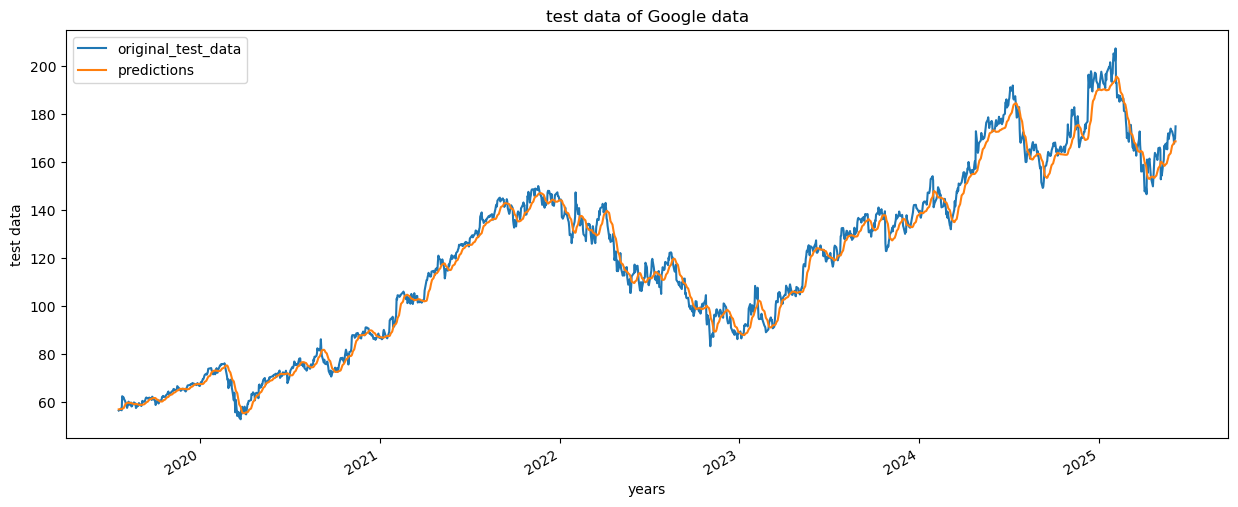

In [57]:
plot_graph((15,6), ploting_data, 'test data')


<Figure size 640x480 with 0 Axes>

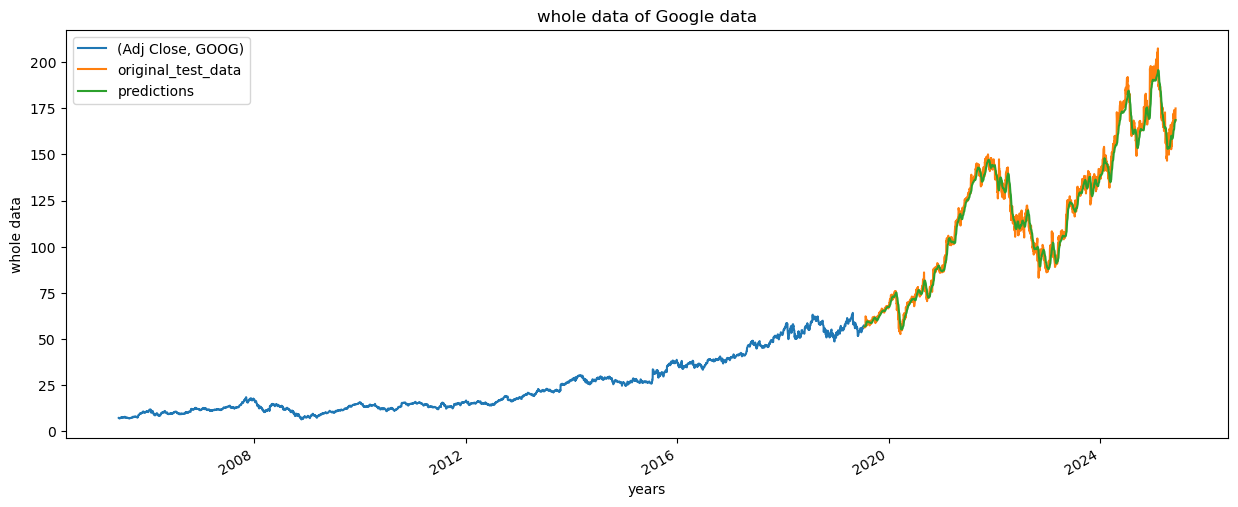

In [59]:
plot_graph((15,6), pd.concat([Adj_close_price[:splitting_len+100],ploting_data], axis=0), 'whole data')


In [60]:

model.save('Latest_stock_price_model.keras')

In [61]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("Keras version:", tf.keras.__version__)

TF version: 2.19.0
Keras version: 3.9.0
